In [1]:
import os
import pandas as pd
import glob
import re
import matplotlib.pyplot as plt
import galpynostatic as gp
import numpy as np
import matplotlib.patches as patches

/home/andres/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# --- Parámetros del rectángulo ---
x0, y0 = -1., -2.
lado = 2
w, h = 1.5 * lado, lado
angle = 30  # grados

# --- Grilla base ---
xs = np.linspace(-4, 2, 128)
ys = np.linspace(-4, 2, 128)
X, Y = np.meshgrid(xs, ys)

# --- Centro y rotación ---
theta = np.deg2rad(angle)
cx, cy = x0 + w/2, y0 + h/2

# Coordenadas en el marco del rectángulo (rotado inversamente)
Xr = (X - cx) * np.cos(-theta) - (Y - cy) * np.sin(-theta)
Yr = (X - cx) * np.sin(-theta) + (Y - cy) * np.cos(-theta)

# --- Máscara del rectángulo ---
mask_inside = (Xr >= -w/2) & (Xr <= w/2) & (Yr >= -h/2) & (Yr <= h/2)
mask_outside = ~mask_inside

# --- Extraer puntos fuera ---
X_out, Y_out = X[mask_outside], Y[mask_outside]
idx_out = np.argwhere(mask_outside)

# --- Seleccionar 20 puntos distribuidos uniformemente ---
sel = np.linspace(0, len(X_out)-1, 20, dtype=int)
pts = np.column_stack([X_out[sel], Y_out[sel]])
idxs = idx_out[sel]

# --- Resultados ---
print("Puntos (x, y):")
print(pts)
print("\nÍndices (i, j):")
print(idxs)

Puntos (x, y):
[[-4.         -4.        ]
 [-0.12598425 -3.76377953]
 [-2.2519685  -3.48031496]
 [ 1.66929134 -3.24409449]
 [-0.45669291 -2.96062992]
 [-2.62992126 -2.67716535]
 [-3.76377953 -2.39370079]
 [-1.16535433 -2.11023622]
 [-3.00787402 -1.73228346]
 [-4.         -1.25984252]
 [-1.07086614 -0.74015748]
 [-1.07086614 -0.26771654]
 [-2.01574803  0.11023622]
 [ 1.71653543  0.39370079]
 [ 0.58267717  0.67716535]
 [-1.59055118  0.96062992]
 [-3.71653543  1.24409449]
 [ 0.20472441  1.48031496]
 [-1.92125984  1.76377953]
 [ 2.          2.        ]]

Índices (i, j):
[[  0   0]
 [  5  82]
 [ 11  37]
 [ 16 120]
 [ 22  75]
 [ 28  29]
 [ 34   5]
 [ 40  60]
 [ 48  21]
 [ 58   0]
 [ 69  62]
 [ 79  62]
 [ 87  42]
 [ 93 121]
 [ 99  97]
 [105  51]
 [111   6]
 [116  89]
 [122  44]
 [127 127]]


In [2]:
diagram = gp.GalvanostaticMap(g=-4)
diagram.run()

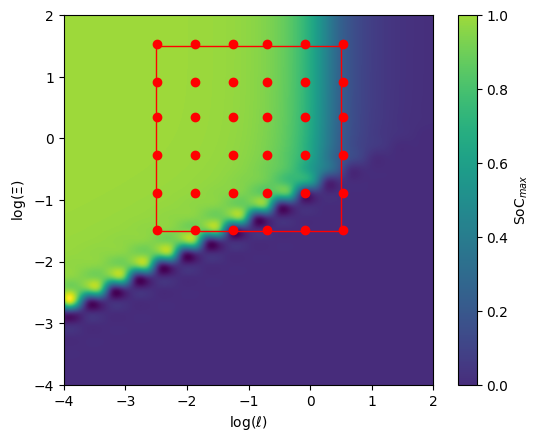

In [40]:
x0, y0 = -2.5, -1.5    
lado = 3 

# Primer panel
ax = plt.subplot()
diagram.map_plot(ax=ax)
rect = patches.Rectangle(
    (x0, y0), lado, lado,
    linewidth=1, edgecolor='red', facecolor='none', angle=0
)
ax.add_patch(rect)
plt.scatter(points[:,0], points[:,1], c='red')
# plt.scatter(points_right[:,0], points_right[:,1], c='green')

In [39]:
import numpy as np

# Grilla base
xs = np.linspace(-4, 2, 128)
ys = np.linspace(-4, 2, 128)

# Cuadrado centrado en (0,0)
x_min, x_max = -2.5, .5
y_min, y_max = -1.5, 1.5

# Número total de puntos
n_points = 40
n_side = int(np.sqrt(n_points))  # grilla cuadrada más cercana (6x6=36)
n_points = n_side ** 2

# Puntos uniformes dentro del cuadrado
xv = np.linspace(x_min, x_max, n_side)
yv = np.linspace(y_min, y_max, n_side)
X, Y = np.meshgrid(xv, yv)
points = np.vstack([X.ravel(), Y.ravel()]).T  # (n_points, 2)

# Ajustar los puntos a la grilla más cercana
ix = np.searchsorted(xs, points[:, 0])
iy = np.searchsorted(ys, points[:, 1])
points = np.column_stack([xs[ix], ys[iy]])
indices = np.column_stack([ix, iy])

# Resultados en formato Python
print("points =", points.tolist())
print("indices =", indices.tolist())

# Y también en formato bash
print("\n# Bash lists")
print("X=({})".format(" ".join(map(str, points[:, 0]))))
print("Y=({})".format(" ".join(map(str, points[:, 1]))))


points = [[-2.4881889763779528, -1.4960629921259843], [-1.8740157480314963, -1.4960629921259843], [-1.2598425196850394, -1.4960629921259843], [-0.6929133858267718, -1.4960629921259843], [-0.07874015748031482, -1.4960629921259843], [0.5354330708661417, -1.4960629921259843], [-2.4881889763779528, -0.8818897637795278], [-1.8740157480314963, -0.8818897637795278], [-1.2598425196850394, -0.8818897637795278], [-0.6929133858267718, -0.8818897637795278], [-0.07874015748031482, -0.8818897637795278], [0.5354330708661417, -0.8818897637795278], [-2.4881889763779528, -0.26771653543307083], [-1.8740157480314963, -0.26771653543307083], [-1.2598425196850394, -0.26771653543307083], [-0.6929133858267718, -0.26771653543307083], [-0.07874015748031482, -0.26771653543307083], [0.5354330708661417, -0.26771653543307083], [-2.4881889763779528, 0.3464566929133861], [-1.8740157480314963, 0.3464566929133861], [-1.2598425196850394, 0.3464566929133861], [-0.6929133858267718, 0.3464566929133861], [-0.0787401574803148